In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

In [4]:
### Load the datasets
df_train = pd.read_csv('car_crash_train.csv')
df_test = pd.read_csv('car_crash_test.csv')

In [5]:
print(df_train.shape)
print(df_test.shape)

(4000, 19)
(1000, 19)


In [6]:
df_train.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float

### Missing Data

In [8]:
df_train.isnull().sum()

Crash Speed (km/h)              0
Impact Angle (degrees)          0
Airbag Deployed                 0
Seatbelt Used                   0
Weather Conditions              0
Road Conditions                 0
Crash Type                      0
Vehicle Type                    0
Vehicle Age (years)             0
Brake Condition                 0
Tire Condition                  0
Driver Age                      0
Driver Experience (years)       0
Alcohol Level (BAC%)            0
Distraction Level            2360
Time of Day                     0
Traffic Density                 0
Visibility Distance (m)         0
Severity                        0
dtype: int64

Missing values in the Distraction levels

In [9]:
missing_rows = df_train[df_train['Distraction Level'].isnull()]

# print(missing_rows)
missing_rows.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
5,162,85,No,No,Clear,Icy,Rear-end,SUV,17,Good,Worn out,38,7,0.091258,NaN,Night,Medium,256,Severe Injury
7,84,30,Yes,Yes,Clear,Dry,Head-on,Truck,15,Good,Good,71,9,0.106204,NaN,Morning,Low,459,Minor Injury


In [10]:
df_train[df_train['Distraction Level'].isnull()].describe()


,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,2360.000000,2360.000000,2360.000000,2360.000000,2360.000000,2360.000000,2360.000000
mean,110.808051,89.990254,9.400847,48.517373,25.104237,0.101156,246.172034
std,52.355083,51.675483,5.766577,17.736894,14.146247,0.058431,142.104640
min,20.000000,0.000000,0.000000,18.000000,0.000000,0.000054,10.000000
25%,66.000000,45.000000,4.000000,34.000000,13.000000,0.049637,122.000000
50%,113.000000,89.000000,9.000000,49.000000,25.000000,0.100762,242.000000
75%,157.000000,134.000000,14.000000,64.000000,37.000000,0.152893,368.250000
max,199.000000,179.000000,19.000000,79.000000,49.000000,0.199936,499.000000


In [11]:
df_train[df_train['Distraction Level'].notnull()].describe()

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000
mean,111.275610,89.964634,9.509756,48.959756,24.174390,0.101301,249.614634
std,52.058899,50.774237,5.648859,17.931354,14.292126,0.056946,145.451401
min,20.000000,0.000000,0.000000,18.000000,0.000000,0.000575,10.000000
25%,68.000000,47.000000,5.000000,33.750000,12.000000,0.051455,119.000000
50%,112.000000,90.000000,9.000000,49.000000,24.000000,0.103489,248.000000
75%,157.000000,133.000000,14.000000,64.000000,36.000000,0.150133,376.500000
max,199.000000,179.000000,19.000000,79.000000,49.000000,0.199776,499.000000


In [12]:
missing_rows_test = df_test[df_test['Distraction Level'].isnull()]
missing_rows_test.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,68,61,No,Yes,Rain,Uneven,Rear-end,Truck,5,Worn out,Good,75,17,0.090047,NaN,Night,Low,111,Minor Injury
2,147,147,Yes,Yes,Snow,Dry,Rear-end,Sedan,8,Good,Good,21,32,0.060945,NaN,Afternoon,High,462,Minor Injury
3,176,35,Yes,Yes,Fog,Wet,Side impact,Motorcycle,6,Good,Good,49,33,0.156030,NaN,Afternoon,High,399,Severe Injury
4,165,94,Yes,Yes,Rain,Dry,Rear-end,SUV,9,Good,Good,41,38,0.112295,NaN,Morning,Medium,395,Minor Injury
5,154,13,No,No,Clear,Dry,Side impact,Sedan,3,Good,Good,33,27,0.157017,NaN,Morning,Low,22,Minor Injury


In [13]:
df_train['Distraction Level'] = (
    df_train['Distraction Level']
    .fillna('No Distraction')
)

df_test['Distraction Level'] = (
    df_test['Distraction Level']
    .fillna('No Distraction')
)

To investigate the missing values in the Distraction Level feature, the statistical distributions of rows with missing and non-missing values were compared. The distributions appeared highly similar across numerical attributes such as crash speed, driver age, alcohol level, and visibility distance, suggesting no strong dependency between the missingness and these variables. Additionally, based on the domain interpretation of the feature, the missing values were treated as indicating the absence of driver distraction. Therefore, missing entries were replaced with the category "No Distraction" instead of removing the rows or applying statistical imputation.

### Class Imbalance Analysis



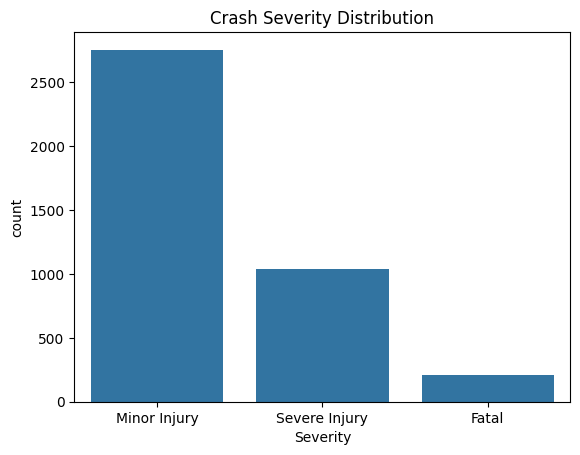

In [14]:
sns.countplot(x='Severity', data=df_train)
plt.title("Crash Severity Distribution")
plt.show()

The target classes exhibited some degree of imbalance, meaning that certain crash severity categories appeared more frequently than others. Class imbalance can negatively affect machine learning models by biasing predictions toward the majority class.

Algorithms such as Logistic Regression, KNN, and Naive Bayes are particularly sensitive to imbalance because they rely heavily on class frequencies, distance distributions, or probability estimates. Although Decision Trees and Random Forests are generally more robust, imbalance can still influence their prediction behavior.

Instead of applying resampling techniques, the imbalance will be addressed during evaluation by using multiple performance metrics beyond accuracy.

Metrics such as precision, recall, F1-score, and confusion matrices were used to provide a more reliable assessment of model performance on both majority and minority classes.

### Feature Correlation


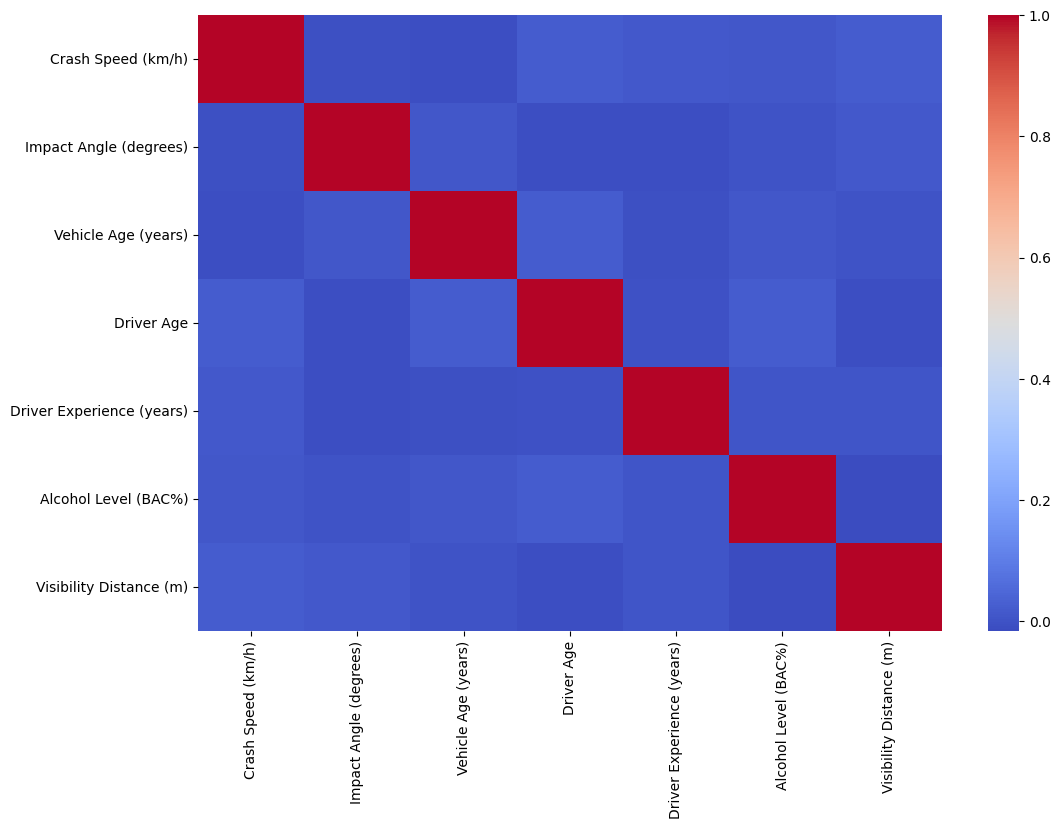

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df_train.corr(numeric_only=True), cmap='coolwarm')
plt.show()

The correlation heatmap shows that most numerical features have weak pairwise correlations, indicating low multicollinearity within the dataset. This suggests that the features provide relatively independent information, which can help improve model generalization. A slight positive correlation can be observed between driver age and driving experience, which is expected in real-world driving data.

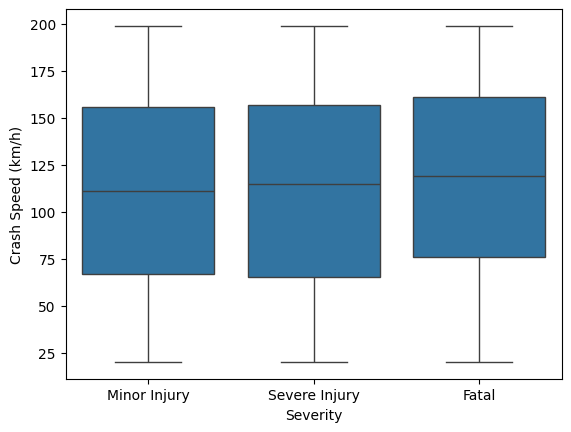

In [16]:
sns.boxplot(
    x='Severity',
    y='Crash Speed (km/h)',
    data=df_train
)

plt.show()

The distribution of crash speeds shows a slight increase in median speed for fatal crashes compared to minor injuries. However, substantial overlap exists between the severity classes, indicating that crash speed alone is insufficient for accurate severity prediction but may still contribute useful predictive information when combined with other features.

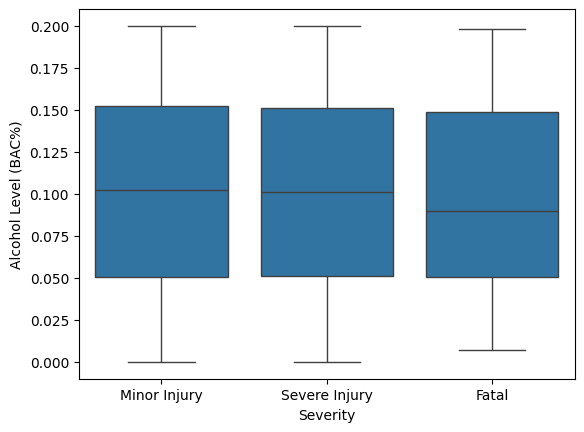

In [17]:
sns.boxplot(
    x='Severity',
    y='Alcohol Level (BAC%)',
    data=df_train
)

plt.show()

The alcohol level distributions are highly similar across the three severity classes. This suggests that alcohol level alone may not strongly distinguish crash severity within this dataset, although it may still contribute useful information when combined with other features.

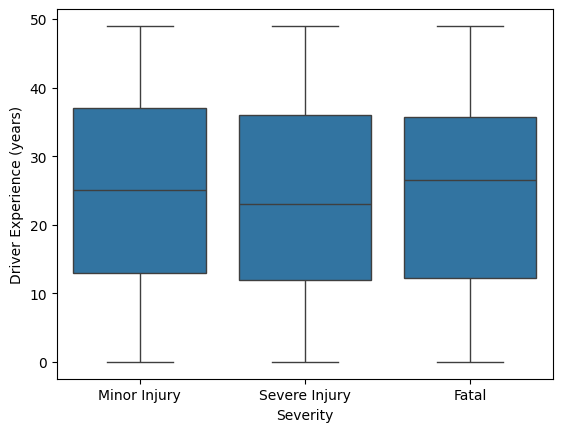

In [18]:
sns.boxplot(
    x='Severity',
    y='Driver Experience (years)',
    data=df_train
)

plt.show()

Driver experience exhibits similar distributions across minor, severe, and fatal crashes. No strong separation between severity classes is observed, indicating that driver experience alone is not a dominant predictor of crash severity.

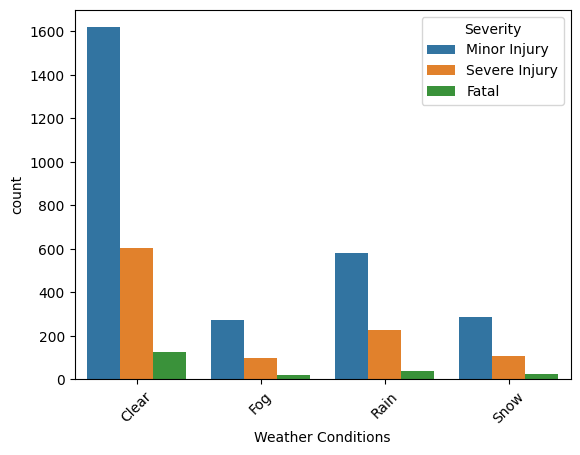

In [19]:
sns.countplot(
    x='Weather Conditions',
    hue='Severity',
    data=df_train
)

plt.xticks(rotation=45)

plt.show()

Most crashes occurred under clear weather conditions, likely because clear weather represents the most common driving environment. Rainy conditions also show a noticeable number of crashes, while fog and snow conditions are less frequent. The severity distribution appears relatively consistent across weather categories, although clear and rainy conditions contribute the highest number of severe and fatal crashes due to their larger overall occurrence.

## Outliers Detection & Handling

In [20]:
numerical_cols = df_train.select_dtypes(
    include=['int64', 'float64']
).columns


print(numerical_cols)

Index(['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
       'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)',
       'Visibility Distance (m)'],
      dtype='object')


In [21]:
outlier_counts = {}

for col in numerical_cols:

    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_train[
        (df_train[col] < lower_bound) |
        (df_train[col] > upper_bound)
    ]

    outlier_counts[col] = len(outliers)

print(outlier_counts)

{'Crash Speed (km/h)': 0, 'Impact Angle (degrees)': 0, 'Vehicle Age (years)': 0, 'Driver Age': 0, 'Driver Experience (years)': 0, 'Alcohol Level (BAC%)': 0, 'Visibility Distance (m)': 0}


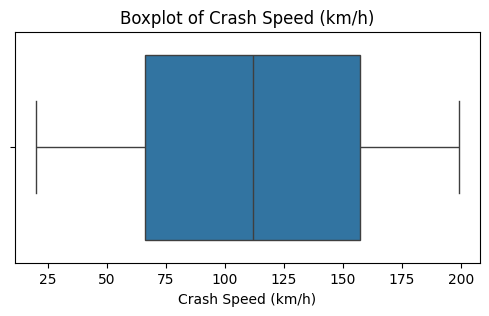

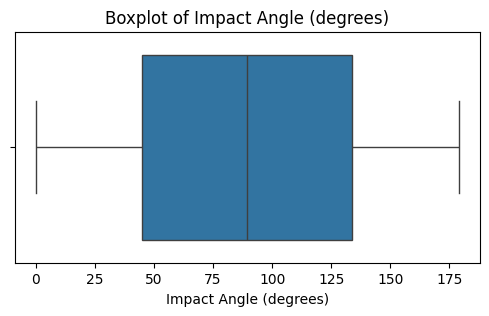

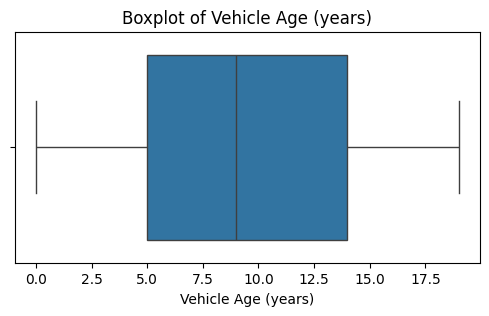

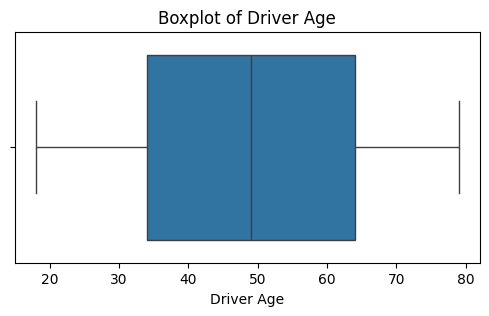

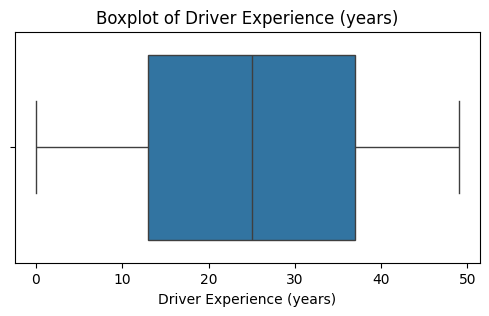

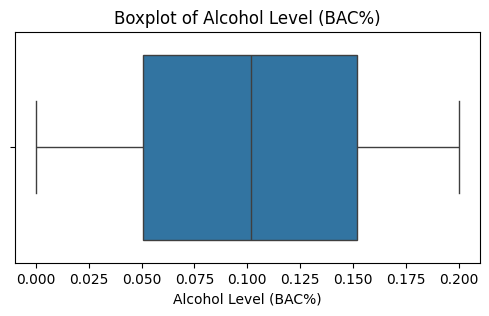

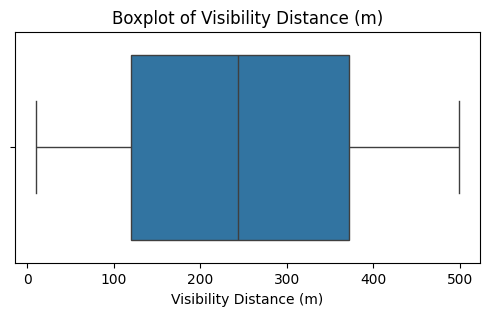

In [22]:
for col in numerical_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df_train[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

No Outliers found in the dataset


## Categorical Encoding


**Label Encoding of the target**

In [23]:
X_train = df_train.drop('Severity', axis=1)

y_train = df_train['Severity']

X_test = df_test.drop('Severity', axis=1)
y_test = df_test['Severity']

In [24]:
target_encoder = LabelEncoder()

y_train_encoded = target_encoder.fit_transform(y_train)

y_test_encoded = target_encoder.transform(y_test)

print("Target Classes:")
print(target_encoder.classes_)

Target Classes:
['Fatal' 'Minor Injury' 'Severe Injury']


In [25]:
# Identify categorical features
categorical_cols = X_train.select_dtypes(
    include='object'
).columns

print("\nCategorical Columns:")
print(categorical_cols)


Categorical Columns:
Index(['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions',
       'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition',
       'Tire Condition', 'Distraction Level', 'Time of Day',
       'Traffic Density'],
      dtype='object')


`fit_transform()` was applied to the training labels because it performs two operations:
1. `fit()` learns the mapping between the categorical class names and numerical labels.
2. `transform()` applies this mapping to convert the labels into numbers.

The test labels were processed using `transform()` only to ensure that the exact same mapping learned from the training data is consistently applied to the test dataset.

This approach prevents inconsistencies in label representation and avoids data leakage between the training and testing phases.

**One-hot Encoding for the rest of the columns**


In [26]:
X_train_encoded = pd.get_dummies(
    X_train,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    drop_first=True
)

In [27]:
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [28]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(4000, 30)
(1000, 30)


### Feature Scaling



In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_encoded
)

X_test_scaled = scaler.transform(
    X_test_encoded
)

### KNN 


In [30]:
# Define parameter grid
param_grid_knn = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create KNN model
knn = KNeighborsClassifier()

# GridSearchCV
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Fit ONLY on training data
grid_knn.fit(X_train_scaled, y_train_encoded)

# Best parameters
print("Best Parameters:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)

# Best model
best_knn = grid_knn.best_estimator_

# Final evaluation on TEST set
y_pred_knn = best_knn.predict(X_test_scaled)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV Score: 0.33444047875115823


**Final KNN Model**

In [31]:
accuracy = accuracy_score(
    y_test_encoded,
    y_pred_knn
)

print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.629


In [32]:
print(classification_report(
    y_test_encoded,
    y_pred_knn,
    target_names=target_encoder.classes_
))

               precision    recall  f1-score   support

        Fatal       0.09      0.15      0.11        41
 Minor Injury       0.74      0.80      0.77       710
Severe Injury       0.34      0.22      0.27       249

     accuracy                           0.63      1000
    macro avg       0.39      0.39      0.38      1000
 weighted avg       0.61      0.63      0.62      1000



In [33]:
cm = confusion_matrix(
    y_test_encoded,
    y_pred_knn
)

print(cm)

[[  6  31   4]
 [ 38 568 104]
 [ 23 171  55]]


The confusion matrix revealed that the KNN classifier strongly favored the majority class (`Minor Injury`) while struggling to correctly classify minority severity classes such as `Fatal` and `Severe Injury`. Although the overall accuracy appeared acceptable, the confusion matrix and class-wise evaluation metrics demonstrated poor recall for minority classes. This highlights the impact of class imbalance on distance-based classifiers such as KNN.

### Decision Trees


In [35]:
dt = DecisionTreeClassifier(class_weight='balanced',random_state=42)
param_grid_dt = {

    'criterion': ['gini', 'entropy'],


    'max_depth': [
        None,
        3,
        5,
        7,
        10,
        15,
        20,
        25,
        30
    ],

    'min_samples_split': [
        2,
        5,
        10,
        20
    ],

    'min_samples_leaf': [
        1,
        2,
        4,
        8,
        16
    ]
}

In [36]:
from sklearn.model_selection import GridSearchCV
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    # scoring='accuracy',
    scoring='f1_macro',
    n_jobs=-1
)

grid_dt.fit(X_train_scaled,
    y_train_encoded)

print("Best DT Parameters:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)


Best DT Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV Score: 0.33615588652521455


In [ ]:
best_dt = grid_dt.best_estimator_

dt_preds = best_dt.predict(X_test_scaled)


print("Accuracy:")

print(accuracy_score(
    y_test_encoded,
    dt_preds
))

print("\nClassification Report:")

print(classification_report(
    y_test_encoded,
    dt_preds,
    target_names=target_encoder.classes_
))

print("\nConfusion Matrix:")

print(confusion_matrix(
    y_test_encoded,
    dt_preds
))


Accuracy:
0.543

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.08      0.12      0.09        41
 Minor Injury       0.72      0.64      0.68       710
Severe Injury       0.28      0.33      0.30       249

     accuracy                           0.54      1000
    macro avg       0.36      0.36      0.36      1000
 weighted avg       0.58      0.54      0.56      1000


Confusion Matrix:
[[  5  29   7]
 [ 46 456 208]
 [ 15 152  82]]


After introducing balanced class weighting and optimizing using macro F1-score, the overall accuracy decreased compared to the earlier Decision Tree model. However, the updated classifier demonstrated significantly improved prediction capability for minority severity classes such as `Fatal` and `Severe Injury`.

This highlights an important characteristic of imbalanced classification problems: higher accuracy does not necessarily indicate better overall model performance. The earlier model achieved higher accuracy primarily by predicting the dominant class (`Minor Injury`) for most samples, while the updated model provides a more balanced classification across all severity categories.

#### Random Forests


In [ ]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {

    'n_estimators': [
        100,
        200
    ],

    'criterion': [
        'gini',
        'entropy'
    ],

    'max_depth': [
        None,
        10,
        20,
        30
    ],

    'min_samples_split': [
        2,
        5,
        10
    ],

    'min_samples_leaf': [
        1,
        2,
        4
    ],


    'class_weight': [
        'balanced'
    ]
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    # scoring='accuracy',
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled,
    y_train_encoded)

print("Best RF Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best RF Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Score: 0.3120802399175696


In [ ]:
best_rf = grid_rf.best_estimator_

rf_preds = best_rf.predict(X_test_scaled)


print("Accuracy:")

print(accuracy_score(
    y_test_encoded,
    rf_preds
))

print("\nClassification Report:")

print(classification_report(
    y_test_encoded,
    rf_preds,
    target_names=target_encoder.classes_
))

print("\nConfusion Matrix:")

print(confusion_matrix(
    y_test_encoded,
    rf_preds
))


Accuracy:
0.658

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      0.89      0.79       710
Severe Injury       0.25      0.11      0.15       249

     accuracy                           0.66      1000
    macro avg       0.32      0.33      0.32      1000
 weighted avg       0.57      0.66      0.60      1000


Confusion Matrix:
[[  0  32   9]
 [  3 630  77]
 [  1 220  28]]


The Random Forest classifier achieved higher overall accuracy and F1-score compared to the single Decision Tree model. The ensemble approach improved generalization and reduced sensitivity to noise in the dataset. However, the confusion matrix indicates that minority classes remain more difficult to classify accurately despite applying imbalance handling techniques.

### Logistic Regression

In [ ]:
log_model = LogisticRegression(

    class_weight='balanced',

    max_iter=5000,

    random_state=42
)

In [ ]:
log_model.fit(X_train_scaled,y_train_encoded)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [ ]:
y_pred = log_model.predict(X_test_scaled)

In [ ]:
accuracy_score(y_test_encoded,y_pred)

0.327

In [ ]:
confusion_matrix(y_test_encoded,y_pred)

array([[ 20,  10,  11],
       [254, 222, 234],
       [ 90,  74,  85]])

In [ ]:
print(classification_report(y_test_encoded,y_pred))

              precision    recall  f1-score   support

           0       0.05      0.49      0.10        41
           1       0.73      0.31      0.44       710
           2       0.26      0.34      0.29       249

    accuracy                           0.33      1000
   macro avg       0.35      0.38      0.28      1000
weighted avg       0.58      0.33      0.39      1000



Logistic Regression demonstrated better detection of the Severe Injury class compared to Random Forest, achieving higher recall for the minority class. Although its overall accuracy was lower, the model showed improved balance in identifying less represented crash severity categories.

### Naive Bayes

In [ ]:
param_grid_nb = {

    'var_smoothing': [
        1e-9,
        1e-8,
        1e-7,
        1e-6,
        1e-5
    ]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_nb = GridSearchCV(

    estimator=GaussianNB(),

    param_grid=param_grid_nb,

    cv=5,

    scoring='f1_macro',

    n_jobs=-1
)

grid_nb.fit(
    X_train_scaled,
    y_train_encoded
)

GridSearchCV(cv=5, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05]},
             scoring='f1_macro')

In [ ]:
best_nb = grid_nb.best_estimator_

nb_preds = best_nb.predict(X_test_scaled)


print("Accuracy:")

print(accuracy_score(
    y_test_encoded,
    nb_preds
))

print("\nClassification Report:")

print(classification_report(
    y_test_encoded,
    nb_preds,
    target_names=target_encoder.classes_
))

print("\nConfusion Matrix:")

print(confusion_matrix(
    y_test_encoded,
    nb_preds
))


Accuracy:
0.7

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.72      0.96      0.82       710
Severe Injury       0.41      0.07      0.12       249

     accuracy                           0.70      1000
    macro avg       0.37      0.34      0.31      1000
 weighted avg       0.61      0.70      0.61      1000


Confusion Matrix:
[[  0  40   1]
 [  3 682  25]
 [  0 231  18]]


Although Naive Bayes achieved good overall accuracy, the confusion matrix shows that the model failed to correctly classify any Fatal cases. The classifier was strongly biased toward the majority class, demonstrating the impact of class imbalance and the limitations of the Naive Bayes independence assumption on this dataset.

### Comparing Algorithms


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Store all model results here
results = []

# Dictionary of trained models
models = {
    "KNN": best_knn,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "Logistic Regression": log_model,
    "Naive Bayes": best_nb
}

# Evaluate each model
for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Metrics
    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_encoded, y_pred, average='weighted', zero_division=0)

    # Macro metrics (important for imbalanced datasets)
    macro_recall = recall_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test_encoded, y_pred, average='macro', zero_division=0)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Weighted Precision": precision,
        "Weighted Recall": recall,
        "Weighted F1": f1,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    })

    # Print detailed report
    print("=" * 60)
    print(f"{name}")
    print("=" * 60)

    print("\nClassification Report:")
    print(classification_report(
        y_test_encoded,
        y_pred,
        target_names=target_encoder.classes_,
        zero_division=0
    ))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_encoded, y_pred))

# Create comparison table
results_df = pd.DataFrame(results)

print("\n\nFINAL MODEL COMPARISON")
print(results_df.sort_values(by="Macro F1", ascending=False))

KNN

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.15      0.05      0.07        41
 Minor Injury       0.72      0.92      0.81       710
Severe Injury       0.34      0.12      0.17       249

     accuracy                           0.68      1000
    macro avg       0.41      0.36      0.35      1000
 weighted avg       0.60      0.68      0.62      1000


Confusion Matrix:
[[  2  35   4]
 [  7 651  52]
 [  4 216  29]]
Decision Tree

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.08      0.12      0.09        41
 Minor Injury       0.72      0.64      0.68       710
Severe Injury       0.28      0.33      0.30       249

     accuracy                           0.54      1000
    macro avg       0.36      0.36      0.36      1000
 weighted avg       0.58      0.54      0.56      1000


Confusion Matrix:
[[  5  29   7]
 [ 46 456 208]
 [ 15 152  82]]
Random Forest

Classificatio

### SMOTE TO IMPROVE ANALYSIS

In [38]:
import sys
!{sys.executable} -m pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

x_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train_encoded
)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\nouna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### KNN using smote

In [39]:
# Define parameter grid
param_grid_knn = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create KNN model
knn = KNeighborsClassifier()

# GridSearchCV
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Fit ONLY on training data
grid_knn.fit(x_train_smote, y_train_smote)

# Best parameters
print("Best Parameters:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)

# Best model
best_knn = grid_knn.best_estimator_

# Final evaluation on TEST set
y_pred_knn = best_knn.predict(X_test_scaled)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Best CV Score: 0.8663574621390993


In [40]:
accuracy = accuracy_score(
    y_test_encoded,
    y_pred_knn
)

print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.546


In [41]:
# Classification Report
print(classification_report(
    y_test_encoded,
    y_pred_knn,
    target_names=target_encoder.classes_
))

               precision    recall  f1-score   support

        Fatal       0.05      0.07      0.06        41
 Minor Injury       0.72      0.67      0.69       710
Severe Injury       0.24      0.27      0.26       249

     accuracy                           0.55      1000
    macro avg       0.34      0.34      0.34      1000
 weighted avg       0.57      0.55      0.56      1000



In [42]:
# Confusion Matrix
print(confusion_matrix(
    y_test_encoded,
    y_pred_knn
))

[[  3  25  13]
 [ 40 476 194]
 [ 19 163  67]]


After applying SMOTE, the KNN classifier showed improved recall for the minority classes, particularly Fatal and Severe Injury cases. This indicates that SMOTE reduced the model’s bias toward the majority class and improved minority-class detection.

However, the overall accuracy decreased, which is expected in imbalanced classification problems since the model became more balanced across all classes rather than focusing mainly on the dominant class.

### Decision Trees with SMOTE

In [43]:
dt = DecisionTreeClassifier(class_weight='balanced',random_state=42)
param_grid_dt = {

    'criterion': ['gini', 'entropy'],


    'max_depth': [
        None,
        3,
        5,
        7,
        10,
        15,
        20,
        25,
        30
    ],

    'min_samples_split': [
        2,
        5,
        10,
        20
    ],

    'min_samples_leaf': [
        1,
        2,
        4,
        8,
        16
    ]

    
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    # scoring='accuracy',
    scoring='f1_macro',
    n_jobs=-1
)

grid_dt.fit(x_train_smote,
    y_train_smote)

print("Best DT Parameters:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

In [ ]:
best_dt = grid_dt.best_estimator_

dt_preds = best_dt.predict(X_test_scaled)


print("Accuracy:")

print(accuracy_score(
    y_test_encoded,
    dt_preds
))

print("\nClassification Report:")

print(classification_report(
    y_test_encoded,
    dt_preds,
    target_names=target_encoder.classes_
))

print("\nConfusion Matrix:")

print(confusion_matrix(
    y_test_encoded,
    dt_preds
))


Accuracy:
0.516

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.02      0.05      0.03        41
 Minor Injury       0.71      0.62      0.66       710
Severe Injury       0.25      0.29      0.27       249

     accuracy                           0.52      1000
    macro avg       0.33      0.32      0.32      1000
 weighted avg       0.56      0.52      0.54      1000


Confusion Matrix:
[[  2  24  15]
 [ 67 442 201]
 [ 17 160  72]]


After applying SMOTE, the Decision Tree classifier showed improved detection of the minority classes compared to the original imbalanced dataset. The model achieved better recall for the Severe Injury class, indicating reduced bias toward the majority class.

However, the classifier still struggled to accurately predict Fatal cases, and some misclassification between severity classes remained present in the confusion matrix.

### Random Forests with SMOTE

In [ ]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {

    'n_estimators': [
        100,
        200
    ],

    'criterion': [
        'gini',
        'entropy'
    ],

    'max_depth': [
        None,
        10,
        20,
        30
    ],

    'min_samples_split': [
        2,
        5,
        10
    ],

    'min_samples_leaf': [
        1,
        2,
        4
    ],


    'class_weight': [
        'balanced'
    ]
}

In [ ]:

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    # scoring='accuracy',
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(x_train_smote,
    y_train_smote)

print("Best RF Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

In [ ]:
best_rf = grid_rf.best_estimator_

rf_preds = best_rf.predict(X_test_scaled)


print("Accuracy:")

print(accuracy_score(
    y_test_encoded,
    rf_preds
))

print("\nClassification Report:")

print(classification_report(
    y_test_encoded,
    rf_preds,
    target_names=target_encoder.classes_
))

print("\nConfusion Matrix:")

print(confusion_matrix(
    y_test_encoded,
    rf_preds
))


Accuracy:
0.683

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      0.95      0.81       710
Severe Injury       0.20      0.03      0.06       249

     accuracy                           0.68      1000
    macro avg       0.30      0.33      0.29      1000
 weighted avg       0.55      0.68      0.59      1000


Confusion Matrix:
[[  0  41   0]
 [  3 675  32]
 [  0 241   8]]


After applying SMOTE, the Random Forest classifier achieved slightly higher overall accuracy. However, the model’s ability to detect minority classes significantly decreased, with the classifier failing to correctly identify Fatal cases and showing very low recall for Severe Injury samples.

These results indicate that although the model performed well on the dominant Minor Injury class, SMOTE did not improve minority-class prediction for Random Forest in this case. This highlights the importance of evaluating recall and F1-score alongside overall accuracy in imbalanced classification problems.

### Logistic Regression

In [ ]:
log_model = LogisticRegression(

    class_weight='balanced',

    max_iter=5000,

    random_state=42
)

In [ ]:
log_model.fit(x_train_smote, y_train_smote)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [ ]:
y_pred = log_model.predict(X_test_scaled)

In [ ]:
#Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test_encoded,y_pred))



Logistic Regression Accuracy: 0.342


In [ ]:
# Classification Report
print(classification_report(
    y_test_encoded, y_pred,
    target_names=target_encoder.classes_
))

               precision    recall  f1-score   support

        Fatal       0.04      0.37      0.08        41
 Minor Injury       0.73      0.34      0.46       710
Severe Injury       0.28      0.35      0.31       249

     accuracy                           0.34      1000
    macro avg       0.35      0.35      0.28      1000
 weighted avg       0.59      0.34      0.41      1000



In [ ]:
# Confusion Matrix
print(confusion_matrix(
    y_test_encoded,
    y_pred
))

[[ 15  14  12]
 [252 239 219]
 [ 88  73  88]]


After applying SMOTE, Logistic Regression achieved significantly better recall for the Fatal class and maintained reasonable detection of Severe Injury cases. This indicates that the model became less biased toward the majority class and more sensitive to minority-class prediction.

However, the overall accuracy decreased considerably, reflecting the tradeoff between balanced class detection and overall classification accuracy in imbalanced datasets.

### Naive Bayes

In [ ]:
param_grid_nb = {

    'var_smoothing': [
        1e-9,
        1e-8,
        1e-7,
        1e-6,
        1e-5
    ]
}

In [ ]:
grid_nb = GridSearchCV(

    estimator=GaussianNB(),

    param_grid=param_grid_nb,

    cv=5,

    scoring='f1_macro',

    n_jobs=-1
)

grid_nb.fit(
    x_train_smote,
    y_train_smote
)

GridSearchCV(cv=5, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05]},
             scoring='f1_macro')

In [ ]:
best_nb = grid_nb.best_estimator_

nb_preds = best_nb.predict(X_test_scaled)


print("Accuracy:")

print(accuracy_score(
    y_test_encoded,
    nb_preds
))

print("\nClassification Report:")

print(classification_report(
    y_test_encoded,
    nb_preds,
    target_names=target_encoder.classes_
))

print("\nConfusion Matrix:")

print(confusion_matrix(
    y_test_encoded,
    nb_preds
))


Accuracy:
0.376

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.04      0.32      0.08        41
 Minor Injury       0.72      0.42      0.53       710
Severe Injury       0.23      0.27      0.25       249

     accuracy                           0.38      1000
    macro avg       0.33      0.33      0.28      1000
 weighted avg       0.57      0.38      0.44      1000


Confusion Matrix:
[[ 13  16  12]
 [210 297 203]
 [ 81 102  66]]


After applying SMOTE, the Naive Bayes classifier showed improved detection of the Fatal and Severe Injury classes compared to the original imbalanced dataset. The recall values for the minority classes increased, indicating reduced bias toward the dominant class.

However, the overall accuracy decreased significantly, and the model still produced considerable misclassification between severity categories. This suggests that the independence assumptions of Naive Bayes remain insufficient for capturing the complex relationships within the crash severity dataset.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Store all model results here
results = []

# Dictionary of trained models
models = {
    "KNN": knn_final,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "Logistic Regression": log_model,
    "Naive Bayes": best_nb
}

# Evaluate each model
for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Metrics
    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_encoded, y_pred, average='weighted', zero_division=0)

    # Macro metrics (important for imbalanced datasets)
    macro_recall = recall_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test_encoded, y_pred, average='macro', zero_division=0)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Weighted Precision": precision,
        "Weighted Recall": recall,
        "Weighted F1": f1,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    })

    # Print detailed report
    print("=" * 60)
    print(f"{name}")
    print("=" * 60)

    print("\nClassification Report:")
    print(classification_report(
        y_test_encoded,
        y_pred,
        target_names=target_encoder.classes_,
        zero_division=0
    ))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_encoded, y_pred))

# Create comparison table
results_df = pd.DataFrame(results)

print("\n\nFINAL MODEL COMPARISON")
print(results_df.sort_values(by="Macro F1", ascending=False))